# Black Hole Trajectory Simulation and Analysis

This notebook simulates and visualizes the trajectories of a test particle around a black hole for various values of angular momentum (L). It demonstrates how to run the simulation, analyze the results, and visualize the orbits and other physical quantities.

## 1. Import Libraries and Define Constants

Import necessary libraries and define physical constants for the simulation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Physical constants
G = 6.67e-11  # Gravitational constant
M = 1e13      # Black hole mass
m = 1.0       # Test particle mass
r_event_horizon = 2.0  # Event horizon radius


## 2. Define Simulation Functions

Define the equations of motion (central force RHS), the RK4 integration step, and a function to run the simulation for a given angular momentum L.

In [2]:
def central_force_rhs(t, Y, L):
    r, v, phi = Y
    return np.array([
        v,
        (L**2)/(m**2 * r**3) - G*M/r**2,
        L/(m*r**2)
    ])

def rk4_step(f, t, y, dt, L):
    k1 = f(t, y, L)
    k2 = f(t + dt/2, y + dt/2*k1, L)
    k3 = f(t + dt/2, y + dt/2*k2, L)
    k4 = f(t + dt,   y + dt*k3, L)
    return y + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

def run_simulation_for_L(L_value, r0=10.0, v0=-0.05, phi0=0.0, t0=0.0, tf=1000.0, dt=0.01):
    Y0 = np.array([r0, v0, phi0])
    ts, Ys = [t0], [Y0.copy()]
    t, Y = t0, Y0.copy()
    while t < tf:
        if Y[0] <= r_event_horizon:
            break
        Y = rk4_step(central_force_rhs, t, Y, dt, L_value)
        t += dt
        ts.append(t)
        Ys.append(Y.copy())
    Ys = np.array(Ys)
    df = pd.DataFrame({
        't': ts,
        'r': Ys[:,0],
        'v': Ys[:,1],
        'phi': Ys[:,2]
    })
    return df


## 3. Run Single Simulation

Run the simulation for a single value of angular momentum (L) and store the results in a DataFrame.

In [3]:
L_single = 46.0  # Example value for L
single_df = run_simulation_for_L(L_single)
single_df.head()

,t,r,v,phi
0,0.00,10.000000,-0.050000,0.000000
1,0.01,9.999272,-0.095542,0.004600
2,0.02,9.998089,-0.141091,0.009201
3,0.03,9.996450,-0.186650,0.013804
4,0.04,9.994356,-0.232222,0.018408


## 4. Visualize Single Simulation Results

Plot the radial distance vs. time, orbital angle vs. time, and the trajectory in the x-y plane for the single simulation.

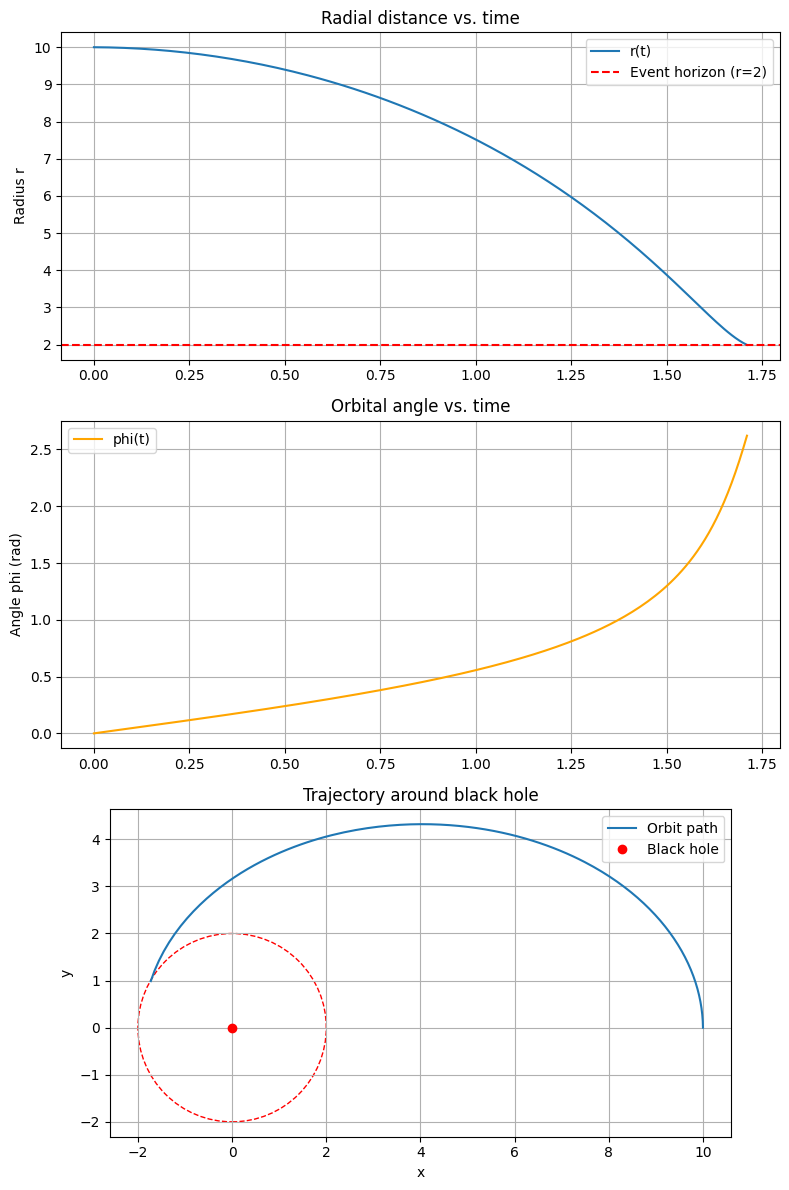

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12))

# r(t)
ax1.plot(single_df['t'], single_df['r'], label="r(t)")
ax1.axhline(r_event_horizon, color='red', linestyle='--', label="Event horizon (r=2)")
ax1.set_ylabel("Radius r")
ax1.set_title("Radial distance vs. time")
ax1.grid(True)
ax1.legend()

# phi(t)
ax2.plot(single_df['t'], single_df['phi'], color='orange', label="phi(t)")
ax2.set_ylabel("Angle phi (rad)")
ax2.set_title("Orbital angle vs. time")
ax2.grid(True)
ax2.legend()

# Orbit in the x-y plane
xs = single_df['r'] * np.cos(single_df['phi'])
ys = single_df['r'] * np.sin(single_df['phi'])
ax3.plot(xs, ys, label="Orbit path")
ax3.plot(0, 0, 'ro', label="Black hole")
horizon = plt.Circle((0,0), r_event_horizon, color='red', fill=False, linestyle='--')
ax3.add_patch(horizon)
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_aspect('equal', 'box')
ax3.set_title("Trajectory around black hole")
ax3.grid(True)
ax3.legend()

fig.tight_layout()
plt.show()

## 5. Run Simulations for Multiple Angular Momentum Values

Run the simulation for a range of L values and store the results in a dictionary for further analysis.

In [5]:
L_values = list(range(1, 11)) + list(range(20, 101, 10))
L_dfs = {}
for L_val in L_values:
    L_dfs[L_val] = run_simulation_for_L(L_val)
    print(f"Simulated for L={L_val}")

Simulated for L=1
Simulated for L=2
Simulated for L=3
Simulated for L=4
Simulated for L=5
Simulated for L=6
Simulated for L=7
Simulated for L=8
Simulated for L=9
Simulated for L=10
Simulated for L=20
Simulated for L=30
Simulated for L=40
Simulated for L=50
Simulated for L=50
Simulated for L=60
Simulated for L=60
Simulated for L=70
Simulated for L=70
Simulated for L=80
Simulated for L=80
Simulated for L=90
Simulated for L=90
Simulated for L=100
Simulated for L=100


## 7. Load and Explore Simulation Results from CSV

Let's load the combined simulation results from the CSV file and demonstrate how to analyze and visualize the data for different values of angular momentum $L$.

In [6]:
# Load the combined results
csv_df = pd.read_csv("all_orbits_data.csv")
from IPython.display import display

print(f"Available L values: {sorted(csv_df['L'].unique())}")
display(csv_df.head())

Available L values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]


,t,r,v,phi,L
0,0.00,10.000000,-0.050000,0.0000,1
1,0.01,9.999167,-0.116695,0.0001,1
2,0.02,9.997666,-0.183405,0.0002,1
3,0.03,9.995498,-0.250140,0.0003,1
4,0.04,9.992663,-0.316908,0.0004,1


### Filter and Analyze Data for a Specific L Value

Select a specific value of $L$ (for example, $L=46$) and plot its trajectory and radial distance over time.

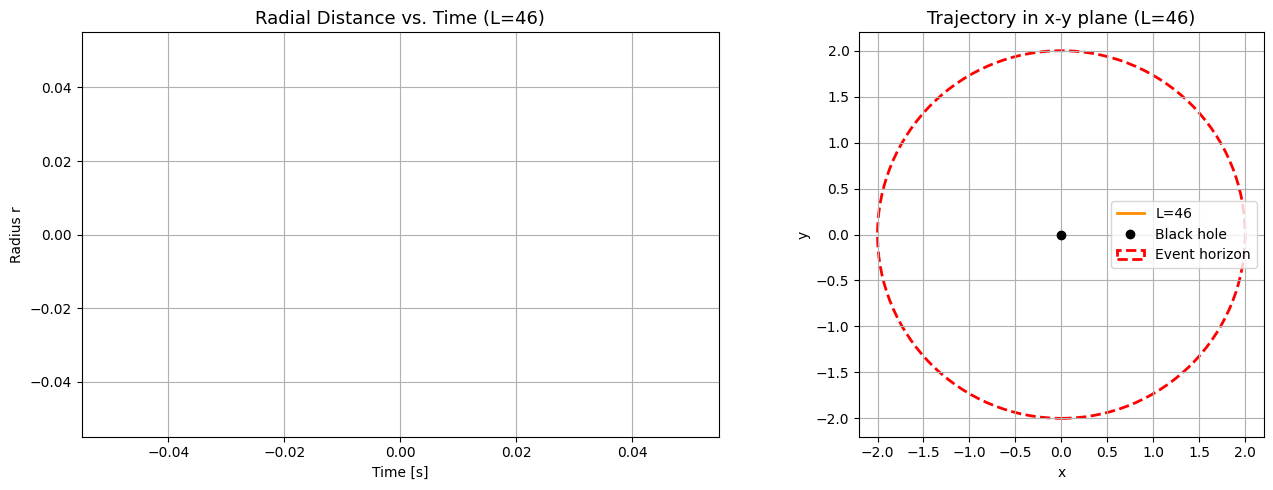

In [7]:
L_selected = 46
L_df = csv_df[csv_df['L'] == L_selected]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot r(t)
ax1.plot(L_df['t'], L_df['r'], color='royalblue', lw=2)
ax1.set_title(f"Radial Distance vs. Time (L={L_selected})", fontsize=13)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Radius r")
ax1.grid(True)

# Plot orbit in x-y plane
xs = L_df['r'] * np.cos(L_df['phi'])
ys = L_df['r'] * np.sin(L_df['phi'])
ax2.plot(xs, ys, color='darkorange', lw=2, label=f"L={L_selected}")
ax2.plot(0, 0, 'ko', label="Black hole")
horizon = plt.Circle((0,0), r_event_horizon, color='red', fill=False, linestyle='--', lw=2, label="Event horizon")
ax2.add_patch(horizon)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title(f"Trajectory in x-y plane (L={L_selected})", fontsize=13)
ax2.set_aspect('equal', 'box')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

### Compare r(t) for Several L Values

Compare the radial distance as a function of time for several different $L$ values on the same plot.

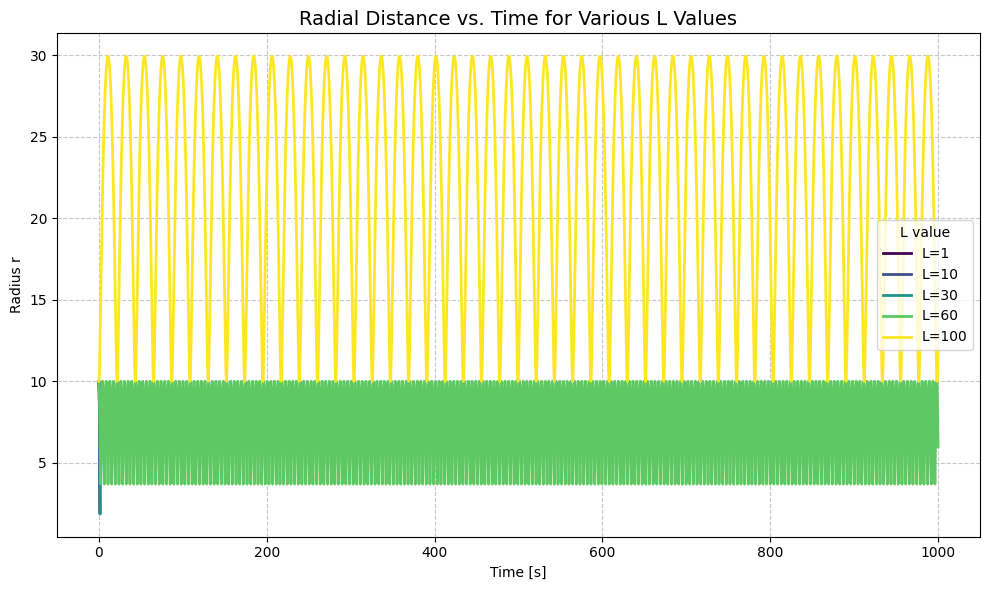

In [8]:
plt.figure(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for i, L_val in enumerate([1, 10, 30, 60, 100]):
    sub_df = csv_df[csv_df['L'] == L_val]
    plt.plot(sub_df['t'], sub_df['r'], label=f"L={L_val}", color=colors[i], lw=2)
plt.title("Radial Distance vs. Time for Various L Values", fontsize=14)
plt.xlabel("Time [s]")
plt.ylabel("Radius r")
plt.legend(title="L value")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insights from the Simulation Data

- For small $L$, the particle quickly falls into the event horizon.
- For large $L$, the particle maintains a more stable, circular-like orbit and does not fall in.
- The $r(t)$ plot shows how angular momentum affects the stability and fate of the orbit.
- The $x$-$y$ trajectory plot visually demonstrates the difference between plunging and stable orbits.
- You can further analyze: for which $L$ the particle never crosses the event horizon, the minimum $r$ reached for each $L$, or the inspiral time as a function of $L$.


# Extreme Mass-Ratio Inspiral (EMRI) Simulation Analysis

This notebook analyzes the trajectories of a test particle around a massive black hole, simulating the early stages of an Extreme Mass-Ratio Inspiral (EMRI) system. We use Runge-Kutta 4th order integration to solve the equations of motion and visualize the orbital dynamics for different angular momentum values.

## Project Context
- We simulate a test particle orbiting a supermassive black hole
- The central force model provides a Newtonian approximation
- RK4 integration ensures accurate trajectory evolution
- Multiple L values help us understand orbital stability conditions

## Analysis Goals

1. Visualize orbital trajectories for various angular momentum values
2. Study the relationship between L and orbital stability
3. Determine conditions for plunge into the event horizon
4. Compare orbital characteristics across different L values

This analysis serves as a foundation for future work on gravitational self-force effects and gravitational wave generation.

## Key Findings

- Low angular momentum (L) orbits tend to plunge quickly into the black hole
- Higher L values can maintain stable orbits outside the event horizon
- There exists a critical L value that separates plunging from stable orbits
- The time to plunge decreases with decreasing angular momentum

These results align with theoretical expectations and provide a basis for more advanced EMRI modeling.

In [9]:
# Load and check L values
csv_df = pd.read_csv("all_orbits_data.csv")
print("Available L values:", sorted(csv_df['L'].unique()))
print("\nNumber of data points per L value:")
print(csv_df.groupby('L').size())

Available L values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]

Number of data points per L value:
L
1         131
2         131
3         131
4         131
5         132
6         132
7         132
8         132
9         132
10        132
20        136
30        144
40        157
50     100002
60     100002
70     100002
80     100002
90     100002
100    100002
dtype: int64
